<a href="https://colab.research.google.com/github/Ritapaz/simulacao-logistica/blob/filas/Simula%C3%A7%C3%A3o_fila_log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

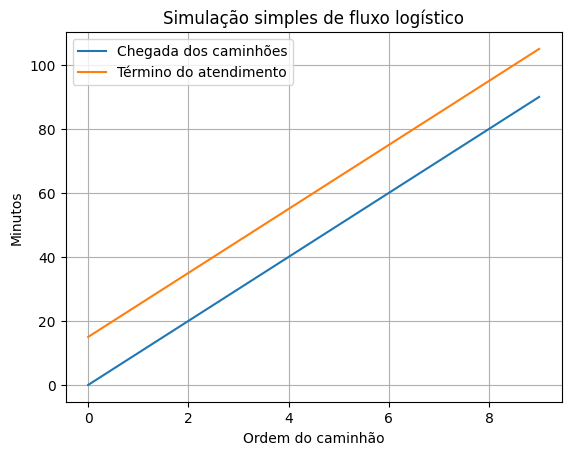

In [7]:
import random
import matplotlib.pyplot as plt

random.seed(42)

chegadas = [i * 10 for i in range(10)]  # caminhões a cada 10 min
atendimentos = [chegada + 15 for chegada in chegadas]  # tempo fixo de atendimento

plt.plot(chegadas, label="Chegada dos caminhões")
plt.plot(atendimentos, label="Término do atendimento")
plt.xlabel("Ordem do caminhão")
plt.ylabel("Minutos")
plt.legend()
plt.title("Simulação simples de fluxo logístico")
plt.grid(True)
plt.show()

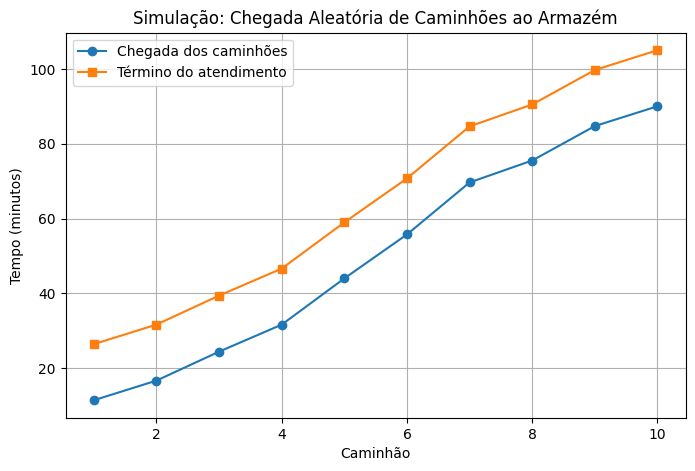

In [8]:
import random
import matplotlib.pyplot as plt

# Definindo semente para reprodutibilidade
random.seed(42)

# Número de caminhões simulados
num_caminhoes = 10

# Geração dos tempos de chegada aleatórios
# Suponha que o tempo entre chegadas siga uma distribuição uniforme de 5 a 15 minutos
intervalos = [random.uniform(5, 15) for _ in range(num_caminhoes)]

# Calcula o tempo acumulado de chegada (soma dos intervalos)
chegadas = [sum(intervalos[:i+1]) for i in range(num_caminhoes)]

# Tempo fixo de atendimento (15 minutos)
atendimentos = [chegada + 15 for chegada in chegadas]

# Visualização
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_caminhoes + 1), chegadas, marker='o', label="Chegada dos caminhões")
plt.plot(range(1, num_caminhoes + 1), atendimentos, marker='s', label="Término do atendimento")
plt.xlabel("Caminhão")
plt.ylabel("Tempo (minutos)")
plt.title("Simulação: Chegada Aleatória de Caminhões ao Armazém")
plt.legend()
plt.grid(True)
plt.show()

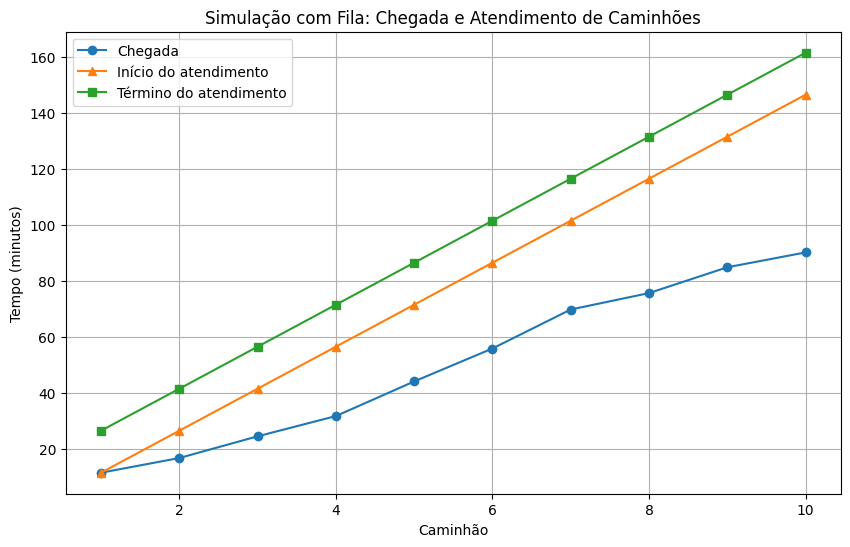

Tempo médio de espera: 28.51 minutos
Tempo médio total no sistema: 43.51 minutos


In [9]:
import random
import matplotlib.pyplot as plt

# Semente para resultados reproduzíveis
random.seed(42)

# Número de caminhões
num_caminhoes = 10

# Tempos entre chegadas (distribuição uniforme entre 5 e 15 minutos)
intervalos_chegada = [random.uniform(5, 15) for _ in range(num_caminhoes)]

# Tempo de chegada acumulado
tempos_chegada = [sum(intervalos_chegada[:i+1]) for i in range(num_caminhoes)]

# Tempo fixo de atendimento por caminhão
tempo_atendimento = 15

# Inicialização das listas de horários de início e fim do atendimento
inicios_atendimento = []
fins_atendimento = []

for i in range(num_caminhoes):
    if i == 0:
        inicio = tempos_chegada[i]
    else:
        # Começa a ser atendido quando chega ou quando o anterior termina, o que for mais tarde
        inicio = max(tempos_chegada[i], fins_atendimento[i-1])
    fim = inicio + tempo_atendimento

    inicios_atendimento.append(inicio)
    fins_atendimento.append(fim)

# Tempo de espera de cada caminhão
tempos_espera = [inicios_atendimento[i] - tempos_chegada[i] for i in range(num_caminhoes)]
tempos_totais = [fins_atendimento[i] - tempos_chegada[i] for i in range(num_caminhoes)]

# Gráfico do processo
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_caminhoes + 1), tempos_chegada, marker='o', label="Chegada")
plt.plot(range(1, num_caminhoes + 1), inicios_atendimento, marker='^', label="Início do atendimento")
plt.plot(range(1, num_caminhoes + 1), fins_atendimento, marker='s', label="Término do atendimento")

plt.xlabel("Caminhão")
plt.ylabel("Tempo (minutos)")
plt.title("Simulação com Fila: Chegada e Atendimento de Caminhões")
plt.grid(True)
plt.legend()
plt.show()

# Estatísticas
tempo_medio_espera = sum(tempos_espera) / len(tempos_espera)
tempo_medio_total = sum(tempos_totais) / len(tempos_totais)

print(f"Tempo médio de espera: {tempo_medio_espera:.2f} minutos")
print(f"Tempo médio total no sistema: {tempo_medio_total:.2f} minutos")

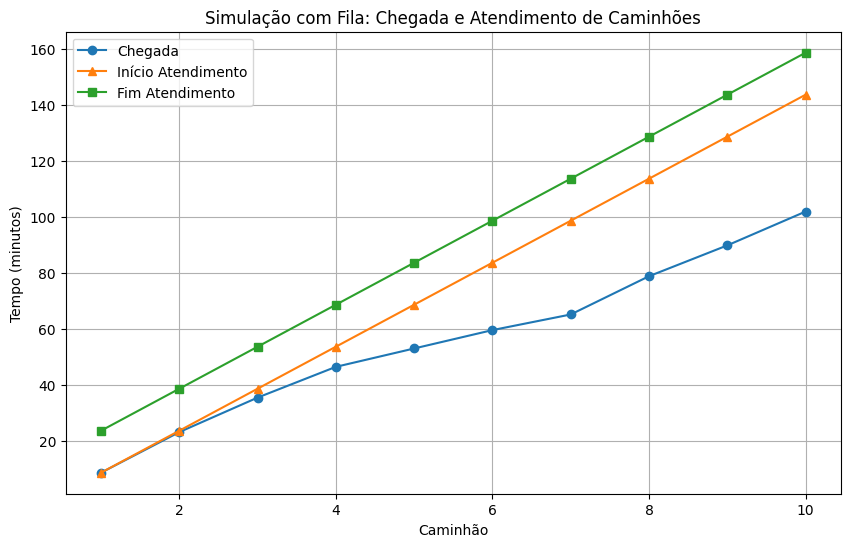

Tempo médio de espera: 19.94 minutos
Tempo médio total no sistema: 34.94 minutos


"interact(\n    simular_fila_logistica,\n    num_caminhoes=IntSlider(min=5, max=30, step=1, value=10, description='Caminhões'),\n    intervalo_min=FloatSlider(min=1, max=10, step=0.5, value=5, description='Interv. Mín'),\n    intervalo_max=FloatSlider(min=10, max=30, step=0.5, value=15, description='Interv. Máx'),\n    tempo_atendimento=IntSlider(min=5, max=30, step=1, value=15, description='Atendimento')\n)"

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def simular_fila_logistica(num_caminhoes=10, intervalo_min=5, intervalo_max=15, tempo_atendimento=15):
    np.random.seed(42)

    # Tempos entre chegadas aleatórios
    intervalos_chegada = np.random.uniform(intervalo_min, intervalo_max, size=num_caminhoes)
    tempos_chegada = np.cumsum(intervalos_chegada)

    inicios_atendimento = []
    fins_atendimento = []

    for i in range(num_caminhoes):
        if i == 0:
            inicio = tempos_chegada[i]
        else:
            inicio = max(tempos_chegada[i], fins_atendimento[i-1])
        fim = inicio + tempo_atendimento
        inicios_atendimento.append(inicio)
        fins_atendimento.append(fim)

    tempos_espera = [inicios_atendimento[i] - tempos_chegada[i] for i in range(num_caminhoes)]
    tempos_totais = [fins_atendimento[i] - tempos_chegada[i] for i in range(num_caminhoes)]

    # Gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_caminhoes + 1), tempos_chegada, marker='o', label="Chegada")
    plt.plot(range(1, num_caminhoes + 1), inicios_atendimento, marker='^', label="Início Atendimento")
    plt.plot(range(1, num_caminhoes + 1), fins_atendimento, marker='s', label="Fim Atendimento")
    plt.xlabel("Caminhão")
    plt.ylabel("Tempo (minutos)")
    plt.title("Simulação com Fila: Chegada e Atendimento de Caminhões")
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"Tempo médio de espera: {np.mean(tempos_espera):.2f} minutos")
    print(f"Tempo médio total no sistema: {np.mean(tempos_totais):.2f} minutos")


simular_fila_logistica()

"""interact(
    simular_fila_logistica,
    num_caminhoes=IntSlider(min=5, max=30, step=1, value=10, description='Caminhões'),
    intervalo_min=FloatSlider(min=1, max=10, step=0.5, value=5, description='Interv. Mín'),
    intervalo_max=FloatSlider(min=10, max=30, step=0.5, value=15, description='Interv. Máx'),
    tempo_atendimento=IntSlider(min=5, max=30, step=1, value=15, description='Atendimento')
)"""
